In [135]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import gym
import matplotlib.pyplot as plt
import random
import argparse
from collections import OrderedDict
from copy import copy
import scipy
import scipy.linalg
import sys
import os
sys.path.append("../utility")
sys.path.append("../train")
sys.path.append("../")
from Utility import data_collecter


from Utility import DerivativeLiftFunc, data_collecter,RBFLiftFunc

In [136]:
Methods = ["KoopmanDerivative","KoopmanRBF",\
            "KNonlinear","KNonlinearRNN","KoopmanU",\
            "KoopmanNonlinearA","KoopmanNonlinear",\
                ]

In [137]:
method_index = 1
# suffix = "CartPole1_26"
# env_name = "CartPole-v1"
# suffix = "Pendulum1_26"
env_name = "Pendulum-v1"
suffix = "DampingPendulum1_26"
# env_name = "DampingPendulum"
# env_name = "LunarLanderContinuous-v2"
# suffix = "MountainCarContinuous1_26"
# env_name = "MountainCarContinuous-v0"
# env_name = "DoublePendulum"

In [138]:
import numpy as np
from typing import Tuple, Optional
Data_collecter = data_collecter(env_name)
Nstate = Data_collecter.Nstates
udim = Data_collecter.udim
NKoopman = 50
import numpy as np
from typing import Tuple, Optional

def angle_normalize(x: float) -> float:
    """角度归一化到[-π, π]，与环境保持一致"""
    return ((x + np.pi) % (2 * np.pi)) - np.pi

class FeedbackLinearizationPendulumController:
    def __init__(
        self,
        n: int = 2,          # 旋转倒立摆状态维度固定为2 [theta, thetadot]
        m: int = 1,          # 输入维度固定为1（力矩）
        u_max: float = 8.0,  # 输入幅值约束（与环境max_torque一致）
        dt: float = 0.02,    # 采样周期（与环境dt一致）
        # 系统物理参数（与环境默认值完全匹配）
        g: float = 10.0,     # 重力加速度
        m_pend: float = 1.0, # 摆杆质量
        l: float = 1.0,      # 摆杆长度
        # 控制器参数
        k_p: float = 80.0,   # 角度比例增益
        k_d: float = 10.0,   # 角速度微分增益    
    ):
        self.n = n
        self.m = m
        self.u_max = u_max
        self.dt = dt
        
        # 系统物理参数
        self.g = g
        self.m_pend = m_pend
        self.l = l
        
        # 控制器参数
        self.k_p = k_p
        self.k_d = k_d
        
        # ==========================================
        # 🔥 反馈线性化预计算（INIT阶段完成，在线零重复计算）
        # ==========================================
        self.mgl_2 = self.m_pend * self.g * self.l / 2.0  # 重力补偿系数 mgl/2
        self.ml2_3 = self.m_pend * self.l**2 / 3.0        # 线性化增益 ml²/3
        
        print(f"[Feedback Linearization Pendulum Controller Initialized]")
        print(f"  State dim: {self.n}, Action dim: {self.m}")
        print(f"  System: m={self.m_pend}kg, l={self.l}m, g={self.g}m/s²")
        print(f"  Precomputed: mgl/2={self.mgl_2:.4f}, ml²/3={self.ml2_3:.4f}")
        print(f"  Gains: k_p={self.k_p}, k_d={self.k_d}")
        
        # 历史数据存储
        self.x_obs_prev = None
        
        self.reset()
    
    def reset(self):
        """重置控制器历史数据和状态（与原代码接口完全一致）"""
        self.x_obs_prev = None
        print(f"[Controller Reset] All history data cleared")
    
    def compute_control(self, x_obs: np.ndarray, x_des: np.ndarray) -> np.ndarray:
        """
        核心控制函数：输入当前状态和期望状态，输出控制力矩
        Args:
            x_obs: 当前观测状态 [theta, thetadot]，角度范围[-π, π]
            x_des: 期望状态 [theta_des, thetadot_des]，通常为[0.0, 0.0]（竖直向上）
        Returns:
            u: 控制力矩（单位N·m），形状为(m,)
        """
        # ==========================================
        # 🔥 入口维度强制检查（与原代码完全一致）
        # ==========================================
        x_obs = np.asarray(x_obs).flatten()
        x_des = np.asarray(x_des).flatten()
        assert x_obs.shape == (self.n,), f"x_obs shape error! Expected ({self.n},), got {x_obs.shape}"
        assert x_des.shape == (self.n,), f"x_des shape error! Expected ({self.n},), got {x_des.shape}"
        
        # 2. 提取状态分量
        theta, thetadot = x_obs
        theta_des, thetadot_des = x_des
        
        # ==========================================
        # 🔥 反馈线性化控制律计算（在线仅需5次浮点运算）
        # ==========================================
        # 步骤1：计算归一化角度误差（处理角度周期性）
        e_theta = angle_normalize(theta - theta_des)
        e_thetad = thetadot - thetadot_des
        
        # 步骤2：计算线性虚拟控制输入v
        v = -self.k_p * e_theta - self.k_d * e_thetad
        
        # 步骤3：计算最终控制力矩u（重力补偿+线性化）
        u = self.ml2_3 * v - self.mgl_2 * np.sin(theta)
        
        # 4. 控制输入幅值约束（与环境一致）
        u = np.clip(u, -self.u_max, self.u_max)
        
        # 5. 更新历史数据
        self.x_obs_prev = x_obs
        
        # 确保输出形状为(m,)，与原代码接口完全一致
        return np.array([u], dtype=np.float64)

In [139]:

def Cost(observations,u_list,Q,R,x_ref):
    steps = observations.shape[1]
    loss = 0
    state_dim = x_ref.shape[0]
    for s in range(steps):
        if s!=steps-1:
            ucost = np.dot(np.dot(u_list[s].T,R),u_list[s])
            loss += ucost[0,0]
        xcost = np.dot(np.dot((observations[:,s]-x_ref).T,Q[:state_dim,:state_dim]),(observations[:,s]-x_ref))
        loss += xcost[0,0]
    return loss
def Prepare_LQR(env_name):
    x_ref = np.zeros(Nstate)
    if env_name.startswith("CartPole"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[1,1] = 0.01
        Q[2,2] = 5.0
        Q[3,3] = 0.01
        R = 0.001*np.eye(1)
        reset_state=  [0.0,-1.0,0.0,0]
    elif env_name.startswith("Pendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 1*np.eye(1)
        reset_state = [-3.0,0.5]
    elif env_name.startswith("DampingPendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 0.08*np.eye(1)
        reset_state = [-3,2]   
    elif env_name.startswith("DoublePendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 5.0
        Q[2,2] = 0
        Q[3,3] = 0
        R = 0.001*np.eye(2)
        reset_state = [-1.5, 0.1, 0, 0]
    elif env_name.startswith("MountainCarContinuous"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 0.001*np.eye(1)
        reset_state = [0.5,0.0]  
        x_ref[0] = 0.45
    elif env_name.startswith("LunarLanderContinuous-v2"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 20.0
        Q[1,1] = 20.0
        Q[2,2] = 5.0
        Q[3,3] = 5.0
        R = 0.001*np.eye(2)
        reset_state = [2.0,0.0]  
        x_ref[0] = 0
        x_ref[1] = 0
        x_ref[-1] = 0
        x_ref[-2] = 0
    Q = np.matrix(Q)
    R = np.matrix(R)
    return Q,R,reset_state,x_ref

[Feedback Linearization Pendulum Controller Initialized]
  State dim: 2, Action dim: 1
  System: m=1.0kg, l=1.0m, g=10.0m/s²
  Precomputed: mgl/2=5.0000, ml²/3=0.3333
  Gains: k_p=10, k_d=5
[Controller Reset] All history data cleared


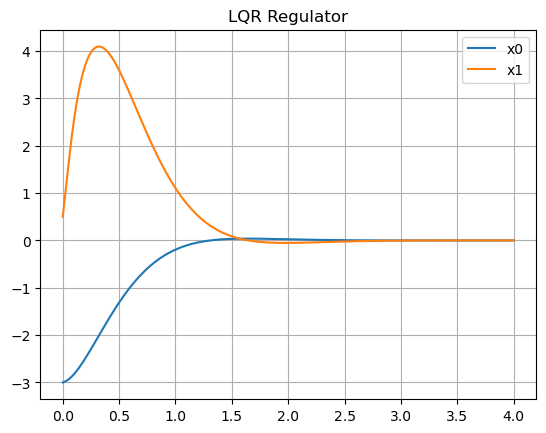

Total cost:  1602.9371987610416


In [140]:
import lqr
import time
env = Data_collecter.env
env.reset()
Controller = FeedbackLinearizationPendulumController(k_p=10,k_d=5)
Q,R,reset_state,x_ref = Prepare_LQR(env_name)
observation_list = []
if env_name == "LunarLanderContinuous-v2":
    observation = env.reset()
else:
    observation = env.reset_state(reset_state)
observation = np.array(observation)
x0 = observation
observation_list.append(observation.reshape(1,-1))
# print(Kopt)
u_list = []
steps = 200
for i in range(steps):
    u = Controller.compute_control(x0,x_ref)
    if udim == 1:
        ureal = u[0]
    else:
        ureal = [u[i] for i in range(udim)]
    observation, reward, done, info = env.step(np.array(ureal))
    x0 = observation
    observation_list.append(observation.reshape(1,-1))
    u_list.append(u)
    # time.sleep(0.1)
# print(observation_list)
observations = np.concatenate(observation_list,axis=0).T

np.save("./data/"+env_name+"_KoopmanRBF"+"_observations.npy",observations)
u_list = np.array(u_list).reshape(-1)
time_history = np.arange(steps+1)*env.dt
for i in range(Nstate):
    plt.plot(time_history, observations[i,:], label="x{}".format(i))
plt.grid(True)
plt.title("LQR Regulator")
plt.legend()
plt.show()
cost = Cost(observations,u_list,Q,R,x_ref)
print("Total cost: ",cost)

In [141]:
from typing import Tuple, List
def test_lander_lqr(
    net,  # 修正类型：适配DKN_MC2
    K_lqr,
    x_ref,
    num_episodes: int = 100,
    max_steps: int = 200,
    version: str = "MCDKN",
    seed: int = 2022
) -> List[float]:
    # 原函数逻辑不变，仅修正psi类型注解
    env = gym.make("LunarLanderContinuous-v2")
    env.seed(seed)
    # device = next(net.parameters()).device
    episode_scores: List[float] = []
    all_trajectories: List[List[Tuple[float, float]]] = []
    landing_positions: List[Tuple[float, float]] = []
    success_count = 0
    # net.eval()
    with torch.no_grad():
        for ep in range(num_episodes):
            observation = env.reset()
            done = False
            total_score = 0.0
            step = 0
            trajectory = []
            x0 = np.matrix(net.Psi_s(observation))
            x_ref_lift = net.Psi_s(x_ref)

            while not done and step < max_steps:
                x0 = x0.T
                trajectory.append((x0[0,0], x0[1,0]))
                # env.render()
                u = -Kopt*(x0-x_ref_lift)
                if udim == 1:
                    ureal = u[0,0]
                else:
                    ureal = [u[i,0] for i in range(udim)]
                # u = max(-umax,min(umax,u[0,0]))
                # print(type(u[0,0]),type(u))
                observation, reward, done, info = env.step(ureal)
                x0 = np.matrix(net.Psi_s(observation))
                # x0 = Ad*x0+Bd*u
                total_score += reward
                step += 1
            x0 = x0.T
            landing_x, landing_y = x0[0,0], x0[1,0]
            landing_positions.append((landing_x, landing_y))
            trajectory.append((landing_x, landing_y))
            all_trajectories.append(trajectory)
            episode_scores.append(total_score)
            if abs(landing_x) <= 0.5 and -0.2 <= landing_y <= 0.2:
                success_count += 1
            print(f"测试回合 {ep+1:2d}/{num_episodes} | 得分：{total_score:5.1f} | 步数：{step:3d} | 落地：(x={landing_x:.3f}, y={landing_y:.3f})")

    env.close()
    # 原落地统计与绘图逻辑不变...
    landing_xs = np.array([p[0] for p in landing_positions], dtype=np.float32)
    landing_ys = np.array([p[1] for p in landing_positions], dtype=np.float32)
    mean_x = np.mean(landing_xs)
    mean_y = np.mean(landing_ys)
    var_x = np.var(landing_xs, ddof=1)
    var_y = np.var(landing_ys, ddof=1)
    std_x = np.sqrt(var_x)
    std_y = np.sqrt(var_y)

    print(f"\n=== 落地位置统计 ===")
    x_ref_np = x_ref
    print(f"目标：(x={x_ref_np[0]:.3f}, y={x_ref_np[1]:.3f}) | 均值：(x={mean_x:.3f}, y={mean_y:.3f})")
    print(f"方差：var_x={var_x:.6f}, var_y={var_y:.6f} | 标准差：std_x={std_x:.3f}, std_y={std_y:.3f}")

    # 原轨迹绘图逻辑不变...
    plt.figure(figsize=(10, 8))
    colors = plt.cm.tab10.colors
    for ep, traj in enumerate(all_trajectories):
        x_coords = [p[0] for p in traj]
        y_coords = [p[1] for p in traj]
        plt.plot(x_coords, y_coords, color=colors[ep % len(colors)], alpha=0.7)

    plt.scatter(x_ref_np[0], x_ref_np[1], color="red", marker="s", s=80, label="Target")
    plt.scatter(mean_x, mean_y, color="blue", marker="o", s=100, label=f"Landing Mean")
    plt.gca().add_patch(plt.Rectangle((mean_x-std_x, mean_y-std_y), 2*std_x, 2*std_y, 
                                     color="blue", alpha=0.2, linestyle="--", label="±1σ"))
    plt.axhline(y=0, color="black", linestyle="--", alpha=0.8, label="Landing Pad")
    plt.xlim(-1.5, 1.5)
    plt.ylim(0, 1.5)
    plt.xlabel("X Position", fontsize=12)
    plt.ylabel("Y Position", fontsize=12)
    plt.title(f"Lunar Lander Trajectory ({version})", fontsize=14)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1), fontsize=10)
    plt.show()
    os.makedirs("./fig/lunarlander", exist_ok=True)
    plt.savefig(f"./fig/lunarlander/trajectory_{version}.png", bbox_inches="tight", dpi=300)
    plt.close()

    avg_score = np.mean(episode_scores)
    std_score = np.std(episode_scores)
    print(f"\n=== 测试总结 ===")
    print(f"平均得分：{avg_score:.1f}±{std_score:.1f} | 成功着陆：{success_count}/{num_episodes}")
    return episode_scores

episode_scores = test_lander_lqr(LiftFunc, Kopt,x_ref)

NameError: name 'LiftFunc' is not defined